# Fase 3 — Preprocesamiento y features

**TP1 — Aprendizaje Automático (72.75) — ITBA** · Consignas **1.1** y **1.4**

Cubrimos el paso **6 (Feature engineering / selection)** del pipeline de la Clase 3.

**Qué decidimos acá:**

1. Cómo convertir las variables categóricas a números *(consigna 1.1)*
2. Si escalamos, y con qué método *(consigna 1.4)*
3. Qué features incluimos *(consigna 1.4)*

Todo queda encapsulado en un objeto que se ajusta **sólo con el train** y después se aplica
al test y a los folds de validación con los mismos parámetros.

In [1]:
# ---------------------------------------------------------------------------
# Configuracion del entorno
# ---------------------------------------------------------------------------
import sys
from pathlib import Path

ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import skew
from sklearn.feature_selection import mutual_info_regression

from src.config import TARGET, RANDOM_SEED, FIGURES_DIR
from src.data import cargar_splits

# Funciones propias, documentadas en src/preprocesamiento.py
from src.preprocesamiento import (
    NUMERICAS,                 # ["age", "bmi", "children"]
    CATEGORICAS,               # ["sex", "smoker", "region"]
    separar_X_y,               # divide un conjunto en X e y
    construir_preprocesador,   # arma el ColumnTransformer
    nombres_de_features,       # nombres de las columnas de salida
)

pd.set_option("display.width", 120)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Cargamos ambos conjuntos. El test se usa solo para DEMOSTRAR como se le aplica
# la transformacion aprendida del train; no se mira su contenido ni su target.
train, test = cargar_splits()
X_train, y_train = separar_X_y(train)

print(f"Train: {X_train.shape[0]} filas | {X_train.shape[1]} variables de entrada")
print(f"Numericas  : {NUMERICAS}")
print(f"Categoricas: {CATEGORICAS}")

Train: 1069 filas | 6 variables de entrada
Numericas  : ['age', 'bmi', 'children']
Categoricas: ['sex', 'smoker', 'region']


---

# 1. Variables categóricas *(consigna 1.1)*

## 1.1 Cuáles son y cuántos niveles tienen

In [2]:
# Cardinalidad (cuantos niveles distintos) y frecuencia de cada nivel.
for col in CATEGORICAS:
    frec = (100 * train[col].value_counts(normalize=True)).round(1)
    print(f"{col:8s} - {train[col].nunique()} niveles: " +
          ", ".join(f"{nivel}={pct}%" for nivel, pct in frec.items()))

sex      - 2 niveles: male=51.4%, female=48.6%
smoker   - 2 niveles: no=80.0%, yes=20.0%
region   - 4 niveles: southeast=26.8%, southwest=24.8%, northwest=24.7%, northeast=23.7%


Las tres son **nominales**: sus niveles son etiquetas sin ningún orden natural.
No existe un criterio que diga que `northeast` "vale más" que `southwest`, ni que `male`
sea mayor que `female`.

Esa observación ya descarta una de las cinco estrategias de la clase.

## 1.2 Las cinco estrategias vistas en clase

| Estrategia | Qué hace | ¿La usamos? |
|---|---|---|
| **Ordinal** | Asigna 1, 2, 3… a cada categoría | ❌ Sólo sirve con jerarquía real |
| **One-hot** | Una columna binaria por categoría | ✅ **Elegida** |
| **Frequency** | Cada categoría toma su frecuencia de aparición | ❌ Ver abajo |
| **Target** | Cada categoría toma la media de `y` de su grupo | ❌ Ver abajo |
| **Regularized target** | Igual, ponderado con la frecuencia (parámetro λ) | ❌ Ver abajo |

**Por qué descartamos el encoding ordinal.** La Clase 2 (slide 14) lo dice explícitamente:
*"sólo es útil cuando hay esa relación jerárquica entre categorías"*. Si codificáramos
`northeast=1, northwest=2, southeast=3, southwest=4`, el modelo lineal interpretaría que
southwest vale cuatro veces northeast y que la distancia northeast→northwest es igual a
southeast→southwest. Estaríamos inventando un orden que no existe.

### Por qué descartamos frequency encoding

La idea (Clase 2, slide 20) es que *"puede ser útil para el algoritmo saber que un dato
pertenece a una categoría muy rara"*. Eso requiere que las frecuencias sean distintas
entre sí. Miramos las nuestras:

In [3]:
# Frequency encoding: cada categoria se reemplazaria por su frecuencia relativa.
frecuencias = train["region"].value_counts(normalize=True).round(4)
print("Valor que tomaria cada region con frequency encoding:")
print(frecuencias.to_string())
print(f"\nAmplitud entre el valor mas alto y el mas bajo: {frecuencias.max() - frecuencias.min():.4f}")
print(f"Diferencia entre southwest y northwest        : "
      f"{abs(frecuencias['southwest'] - frecuencias['northwest']):.4f}")

Valor que tomaria cada region con frequency encoding:
region
southeast    0.2685
southwest    0.2479
northwest    0.2470
northeast    0.2367

Amplitud entre el valor mas alto y el mas bajo: 0.0318
Diferencia entre southwest y northwest        : 0.0009


**Las cuatro regiones están casi perfectamente balanceadas**: van de 0.2367 a 0.2685.
Con frequency encoding, `southwest` (0.2479) y `northwest` (0.2470) quedarían con valores
que difieren en **0.0009** — el modelo no podría distinguirlas.

Frequency encoding sirve cuando hay categorías raras que se comportan distinto. Acá no hay
ninguna categoría rara: **el método comprimiría cuatro grupos diferentes en cuatro números
casi idénticos y perdería toda la información**.

### Por qué descartamos target encoding (y su versión regularizada)

Reemplazar cada región por la media de `charges` de su grupo es tentador, pero tiene dos
problemas en nuestro caso:

**1. Riesgo de leakage.** El target encoding usa el valor de `y` para construir una
variable de entrada. Si se calcula una sola vez sobre todo el train y después se hace
k-fold, cada fold de validación contribuyó a la media que el modelo usa para predecirlo:
el error de validación saldría optimista. Para hacerlo bien habría que recalcularlo dentro
de cada fold. Es posible, pero agrega complejidad sin necesidad.

**2. No resuelve ningún problema que tengamos.** El peligro que la Clase 2 (slide 22)
señala —*"si hay pocos datos de esa categoría, el promedio puede no ser directamente la y a
estimar"*— aplica a variables de alta cardinalidad. Nuestra región con menos datos tiene
253 observaciones: no hay escasez que corregir. Y el **regularized target encoding**
existe justamente para amortiguar ese problema con un parámetro λ; sin el problema, sólo
agregaría un hiperparámetro más para ajustar.

## 1.3 Decisión: one-hot encoding

**Elegimos one-hot para las tres variables**, con `drop="first"`.

**Motivos:**

1. **Respeta la naturaleza nominal**: no inventa ningún orden entre categorías.
2. **No hay leakage posible**: la transformación no mira el target.
3. **El costo en dimensionalidad es despreciable.** La Clase 2 (slide 18) advierte que
   one-hot *"aumenta la dimensionalidad mucho"* y que *"está bien si no hay muchas
   variables categóricas o muchas categorías"* — que es exactamente nuestro caso:
   3 variables con 2, 2 y 4 niveles.

**Por qué `drop="first"`:** si dejáramos las 4 columnas de `region`, su suma sería siempre 1
y el modelo ya tiene un intercepto que también vale 1 para todos. Eso hace que los
coeficientes dejen de ser únicos (la *trampa de las variables dummy*). Descartando una
categoría, ésta queda como referencia y las demás se leen respecto de ella.

**Resultado:** las 6 variables originales pasan a **8 columnas**.

| Original | Columnas generadas | Categoría de referencia |
|---|---|---|
| `sex` | `sex_male` | `female` |
| `smoker` | `smoker_yes` | `no` |
| `region` | `region_northwest`, `region_southeast`, `region_southwest` | `northeast` |

---

# 2. Escalado *(consigna 1.4)*

## 2.1 ¿Hace falta escalar?

Miramos primero las escalas con las que trabajamos.

In [4]:
# Rango y dispersion de cada variable numerica, sin escalar.
print(train[NUMERICAS].agg(["min", "max", "mean", "std"]).T.round(2).to_string())

            min    max   mean    std
age       18.00  64.00  39.20  14.00
bmi       15.96  53.13  30.54   6.05
children   0.00   5.00   1.08   1.19


`age` tiene un desvío de 14.0 y `children` de 1.19: **una es doce veces más dispersa que
la otra**. Y las columnas one-hot valen 0 o 1.

**Para la regresión lineal por mínimos cuadrados, esto no cambia nada.** Los coeficientes
absorben las unidades: si `age` está en años o en meses, el coeficiente se ajusta y la
predicción es idéntica.

**Pero sí importa con regularización L1 (consigna 3.3, Fase 5).** La penalización de Lasso
es λ·Σ|w|: castiga coeficientes grandes. Y un coeficiente es "grande" o "chico" **según las
unidades de su variable**. Sin escalar, una variable con valores pequeños necesita
coeficientes grandes para tener el mismo efecto, y la penalización la castigaría más — no
por ser menos útil, sino por sus unidades.

**Escalamos, entonces, para que la regularización trate a todas las variables por igual.**

## 2.2 z-score o min-max

La Clase 3 (slides 42–43) presenta las dos opciones:

| Método | Fórmula | Contra |
|---|---|---|
| **min-max** | (x − min) / (max − min) | *"Muy sensible a outliers"* (slide 42) |
| **z-score** | (x − media) / desvío | *"Se usa por defecto en la mayoría de modelos, mucho menos sensible a outliers"* (slide 43) |

**Elegimos z-score (`StandardScaler`).** Además del criterio de la clase, en nuestro caso
pesa que min-max se define **enteramente por el mínimo y el máximo**: un único valor extremo
de `bmi` fijaría la escala de toda la variable. Como en la Fase 2 decidimos **conservar los
valores extremos**, usar un método que depende de ellos sería contradictorio.

## 2.3 Qué escalamos y qué no

**Escalamos las tres numéricas. Dejamos las columnas one-hot como 0/1.**

Las dummies ya están en un rango acotado y comparable: sus desvíos van de 0.40 a 0.50, del
mismo orden que una variable estandarizada (desvío 1). Escalarlas además haría más difícil
leer los coeficientes y amplificaría las categorías menos frecuentes.

---

# 3. Selección de features *(consigna 1.4)*

La consigna pide decidir qué características se incluyen —*"pueden ser todas"*— y
justificarlo.

Aplicamos **filtros**, la primera de las tres familias de la Clase 3 (slide 63):
estadísticos univariados, independientes del modelo. Son rápidos, pero no ven interacciones
entre variables — por eso los usamos como **diagnóstico**, no como decisión automática.

## 3.1 Pearson e información mutua

Usamos dos filtros porque miden cosas distintas:

- **Correlación de Pearson**: mide relación **lineal**. La Clase 3 (slide 65) advierte que
  *"únicamente capta relaciones lineales"*.
- **Información mutua** (slide 66): mide *"cuánta incertidumbre sobre Y reducimos por
  conocer X"*. Detecta relaciones **no lineales**.

Los calculamos sobre las features **ya codificadas**, que es como las va a ver el modelo.

In [5]:
# Aplicamos el preprocesador para obtener las 8 columnas finales.
# Lo ajustamos solo con train, que es el unico conjunto que podemos mirar.
preprocesador = construir_preprocesador()
X_train_proc = preprocesador.fit_transform(X_train)
nombres = nombres_de_features(preprocesador)

X_proc = pd.DataFrame(X_train_proc, columns=nombres, index=X_train.index)

# Pearson: correlacion lineal de cada feature con el target (en valor absoluto).
pearson = X_proc.corrwith(y_train).abs()

# Informacion mutua: relacion de cualquier tipo. random_state fija el resultado,
# porque el estimador usa vecinos mas cercanos con ruido aleatorio.
info_mutua = pd.Series(
    mutual_info_regression(X_proc, y_train, random_state=RANDOM_SEED),
    index=nombres,
)

filtros = pd.DataFrame({"pearson_abs": pearson.round(3), "info_mutua": info_mutua.round(3)})
filtros["rank_pearson"] = filtros["pearson_abs"].rank(ascending=False).astype(int)
filtros["rank_MI"] = filtros["info_mutua"].rank(ascending=False).astype(int)
filtros.sort_values("info_mutua", ascending=False)

,pearson_abs,info_mutua,rank_pearson,rank_MI
age,0.290,1.444,2,1
smoker_yes,0.774,0.351,1,2
children,0.086,0.158,4,3
sex_male,0.060,0.137,6,4
bmi,0.178,0.075,3,5
region_northwest,0.055,0.042,7,6
region_southeast,0.079,0.028,5,7
region_southwest,0.036,0.014,8,8


**Tres lecturas:**

**1. Codificada, `smoker` domina.** `smoker_yes` tiene una correlación de Pearson de
**0.774** con el target: cuatro veces más que cualquier otra. En la Fase 2 Pearson no la
veía porque era una columna de texto; una vez convertida a 0/1, la detecta sin problema.

**2. Los dos filtros no coinciden, y está bien.** Pearson pone a `smoker_yes` primero;
información mutua pone a `age`. No se contradicen: miden cosas distintas y sus valores no
son comparables entre sí (la MI de una variable continua y una binaria están en escalas
diferentes). Lo que importa es que **ambos ubican a `smoker_yes` y `age` arriba, y a las
regiones abajo**.

**3. Ninguna feature da cero.** Incluso `region_southwest`, la última en ambos rankings,
aporta algo. No hay ninguna variable que sea puro ruido.

## 3.2 ¿Hay redundancia entre features?

In [6]:
# Correlacion absoluta entre features, ignorando la diagonal.
corr_features = X_proc.corr().abs()
sin_diagonal = corr_features.where(~np.eye(len(corr_features), dtype=bool))
var_a, var_b = sin_diagonal.stack().idxmax()
print(f"Correlacion absoluta maxima entre features: {sin_diagonal.max().max():.3f} "
      f"({var_a} - {var_b})")

Correlacion absoluta maxima entre features: 0.348 (region_southeast - region_southwest)


El máximo es **0.348**, entre dos dummies de `region`. Eso **no es redundancia
informativa**: las columnas one-hot de una misma variable están mecánicamente
anticorrelacionadas, porque si una vale 1 las otras valen 0 por construcción.

Entre variables distintas, la correlación es mucho menor. **No hay features que digan lo
mismo.**

## 3.3 Decisión: conservamos las 6 variables

**Motivos:**

1. **Ninguna es irrelevante**: las dos medidas de filtro dan valores mayores que cero para
   todas.
2. **Ninguna es redundante**: la correlación entre variables distintas es baja.
3. **No hay maldición de la dimensionalidad.** La Clase 3 (slide 59) advierte que muchas
   dimensiones vuelven los datos dispersos. Con 8 columnas y 1069 filas estamos lejos: la
   "regla del 10×" de la Clase 2 (slide 91) pediría unas 80 observaciones y tenemos más de
   mil.

> **Dónde sí va a hacer falta seleccionar.** El panorama cambia en la Fase 5: la
> transformación polinómica de grado 2 lleva estas 8 columnas a unas 45, y la de grado 3 a
> más de 160. Ahí la relación entre datos y parámetros se pone incómoda y la selección hace
> trabajo real, con las otras dos familias de la Clase 3: **wrapper** (RFE) y **embedded**
> (Lasso L1). Los filtros de esta fase son el diagnóstico previo.

---

# 4. ¿Conviene transformar el target?

En la Fase 2 vimos que `charges` es muy asimétrica. La Clase 2 (slide 42) menciona las
*"transformaciones estadísticas que reducen el efecto de los outliers"* como una de las tres
estrategias válidas. La evaluamos.

skew(charges)      =  1.508   (muy asimetrica)
skew(log(charges)) = -0.102   (practicamente simetrica)


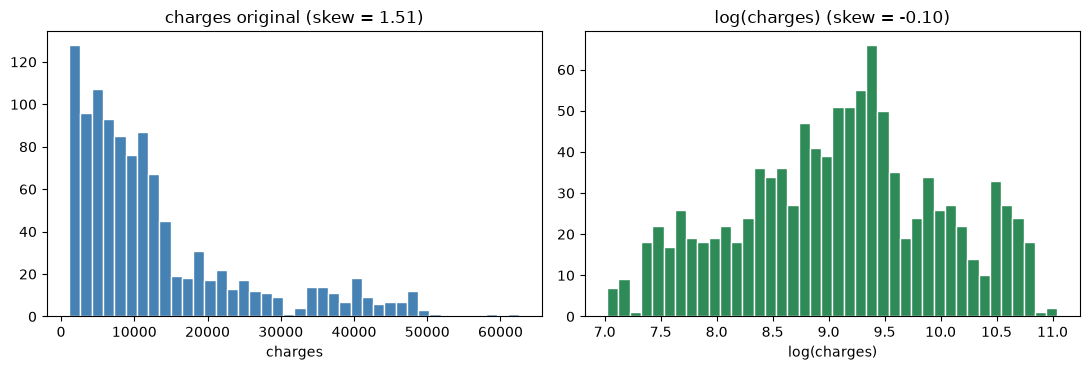

In [7]:
# El coeficiente de asimetria (skew) mide cuan desbalanceada esta la distribucion.
# 0 = simetrica; > 1 = cola derecha pesada.
skew_original = skew(y_train)
skew_log = skew(np.log(y_train))

print(f"skew(charges)      = {skew_original:6.3f}   (muy asimetrica)")
print(f"skew(log(charges)) = {skew_log:6.3f}   (practicamente simetrica)")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
axes[0].hist(y_train, bins=40, color="steelblue", edgecolor="white")
axes[0].set_title(f"charges original (skew = {skew_original:.2f})")
axes[0].set_xlabel("charges")
axes[1].hist(np.log(y_train), bins=40, color="seagreen", edgecolor="white")
axes[1].set_title(f"log(charges) (skew = {skew_log:.2f})")
axes[1].set_xlabel("log(charges)")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "03_transformacion_log_target.png", dpi=150, bbox_inches="tight")
plt.show()

**El logaritmo corrige la asimetría casi por completo** (de 1.51 a −0.10).

**Decidimos NO aplicarlo**, por dos razones:

1. **El RMSE dejaría de estar en dólares.** El enunciado pide reportar RMSE y comparar
   modelos con esa métrica. Un RMSE calculado sobre `log(charges)` mide error en unidades
   logarítmicas y **no es comparable** con el de los modelos sin transformar. Para
   compararlos habría que deshacer la transformación al predecir, lo que además introduce un
   sesgo conocido (la exponencial de la media no es la media de la exponencial).
2. **No resuelve el problema real.** La asimetría de `charges` no es ruido: es la separación
   entre fumadores y no fumadores, que ya identificamos en la Fase 2. La forma de
   aprovecharla es darle al modelo la variable que la explica —`smoker`, que ya está
   incluida— y los términos de interacción de la Fase 5.

Queda documentado como **línea de mejora**: si el modelo final tuviera errores muy
desbalanceados entre casos baratos y caros, sería el primer experimento a probar.

---

# 5. El preprocesador

## 5.1 Construcción

Todo lo decidido se encapsula en un único `ColumnTransformer`, definido en
`src/preprocesamiento.py`.

In [8]:
# Construimos el objeto (todavia sin ajustar) y lo mostramos.
preprocesador = construir_preprocesador()
preprocesador

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. ``""{feature_name}__{transformer_name}""``. See :meth:`str.format` method from the standard library for more info... versionadded:: 1.0.. versionchanged:: 1.6 `verbose_feature_names_out` can be a callable or a string to be formatted.",False
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The

## 5.2 La demostración importante: se ajusta sólo con train

Ésta es la celda que muestra en concreto la regla que venimos aplicando desde la Fase 1.

- `fit_transform(X_train)` → **aprende** la media y el desvío del train y transforma.
- `transform(X_test)` → **aplica esos mismos parámetros**, sin recalcular nada.

Si el escalado del test se calculara con los datos del test, sus columnas darían media 0 y
desvío 1. **No deben dar eso**: deben quedar cerca, pero no exactamente.

In [9]:
# 1) Ajustamos con train: aprende media y desvio de age, bmi y children.
X_train_proc = preprocesador.fit_transform(X_train)
nombres = nombres_de_features(preprocesador)

# 2) Aplicamos al test SIN reajustar (transform, no fit_transform).
X_test, _y_test_no_mirar = separar_X_y(test)
X_test_proc = preprocesador.transform(X_test)

df_tr = pd.DataFrame(X_train_proc, columns=nombres)
df_te = pd.DataFrame(X_test_proc, columns=nombres)

print("Parametros APRENDIDOS del train:")
escalador = preprocesador.named_transformers_["num"]
print(pd.DataFrame({"media_train": escalador.mean_, "desvio_train": escalador.scale_},
                   index=NUMERICAS).round(3).to_string())

print("\nTRAIN transformado (por construccion: media 0, desvio 1):")
print(df_tr[NUMERICAS].agg(["mean", "std"]).round(4).to_string())

print("\nTEST transformado con los parametros del train (NO da 0 y 1):")
print(df_te[NUMERICAS].agg(["mean", "std"]).round(4).to_string())

Parametros APRENDIDOS del train:
          media_train  desvio_train
age            39.198        13.992
bmi            30.540         6.049
children        1.084         1.194

TRAIN transformado (por construccion: media 0, desvio 1):
         age     bmi  children
mean  0.0000  0.0000    0.0000
std   1.0005  1.0005    1.0005

TEST transformado con los parametros del train (NO da 0 y 1):
         age     bmi  children
mean  0.0085  0.1015    0.0482
std   1.0185  1.0379    1.0460


**Los números del test no son 0 y 1** —dan medias de 0.01 a 0.10 y desvíos de 1.02 a
1.04— y eso es exactamente lo que queremos ver: **confirma que el test fue transformado con
los parámetros del train**, no con los suyos.

Si diera exactamente 0 y 1, sería la señal de que el escalador se reajustó con el test: data
leakage.

## 5.3 Cómo lo usan las fases siguientes

En la Fase 4 el preprocesador entra dentro de un `Pipeline` junto con el modelo:

```python
modelo = Pipeline([
    ("preprocesamiento", construir_preprocesador()),
    ("regresion", LinearRegression()),
])
```

**Por qué así y no aplicando la transformación antes:** dentro de un `Pipeline`, la
validación cruzada **reajusta el preprocesamiento en cada fold**. Si en cambio ajustáramos
el escalador una sola vez sobre todo el train y después hiciéramos el k-fold, cada fold de
validación habría participado en el cálculo de esa media y ese desvío, y el error de
validación saldría optimista.

Es la regla 2 del proyecto convertida en código: imposible de olvidar.

---

## Conclusiones de la Fase 3

| Decisión | Valor | Motivo |
|---|---|---|
| Encoding de `sex`, `smoker`, `region` | **One-hot con `drop="first"`** | Son nominales; no hay leakage; el costo en dimensionalidad es mínimo |
| Ordinal | Descartado | No hay jerarquía entre las categorías |
| Frequency | Descartado | Las 4 regiones tienen frecuencias casi iguales (0.2367–0.2685): colapsarían en un mismo valor |
| Target / Regularized target | Descartados | Riesgo de leakage y ningún problema de cardinalidad que resolver (mín. 253 obs. por categoría) |
| Escalado | **z-score (`StandardScaler`)** sobre las numéricas | Clase 3 slide 43; imprescindible para que L1 penalice de forma pareja |
| Columnas one-hot | Sin escalar | Ya están en 0/1, con desvíos de 0.40–0.50 |
| Features incluidas | **Las 6** → 8 columnas | Ninguna irrelevante, ninguna redundante, sin problema de dimensionalidad |
| Transformación del target | **No aplicada** | El RMSE dejaría de estar en dólares y de ser comparable |

**Siguiente:** Fase 4 — Regresión lineal con k-fold sobre el train (consignas 2.2 y 2.3).